In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df = pd.read_csv("../data/titanic.csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


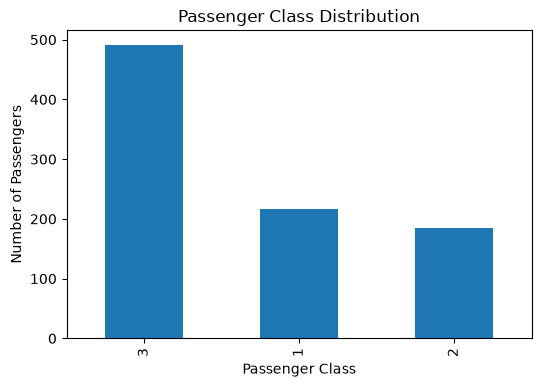

In [4]:
plt.figure(figsize=(6,4))
df["Pclass"].value_counts().plot(kind="bar")

plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

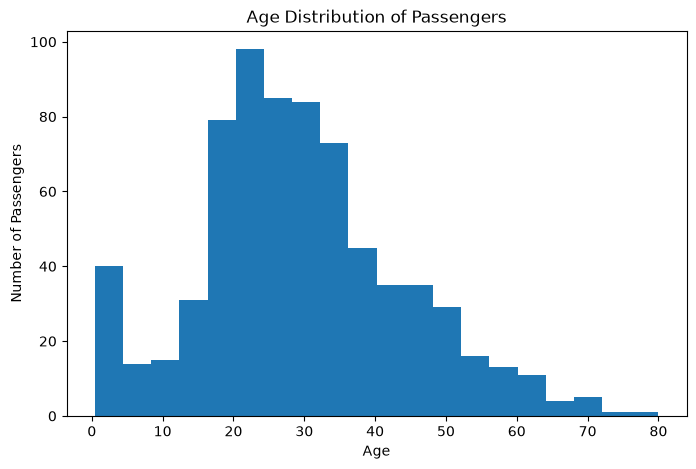

In [5]:
plt.figure(figsize=(8,5))

plt.hist(df["Age"].dropna(), bins=20)

plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

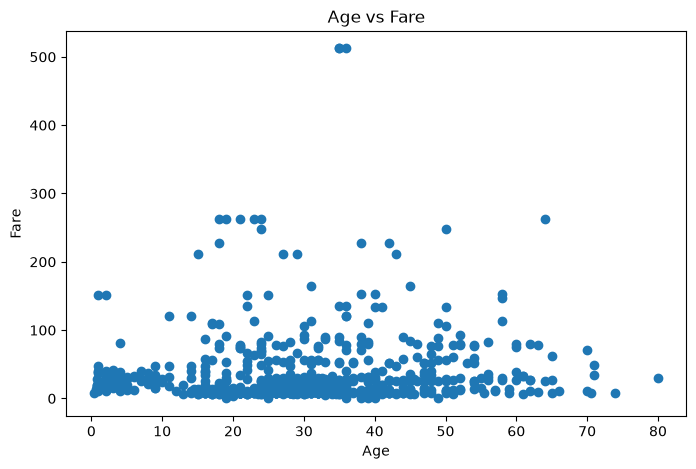

In [6]:
plt.figure(figsize=(8,5))

plt.scatter(df["Age"], df["Fare"])

plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.show()

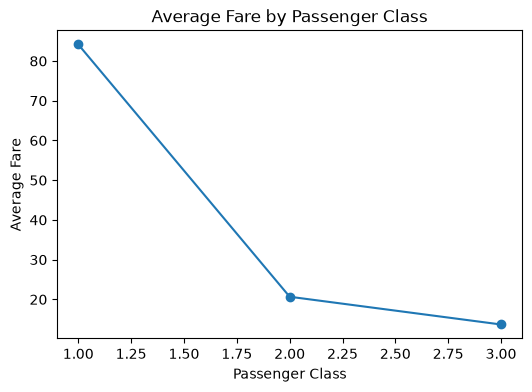

In [7]:
avg_fare = df.groupby("Pclass")["Fare"].mean()

plt.figure(figsize=(6,4))

plt.plot(avg_fare.index, avg_fare.values, marker="o")

plt.title("Average Fare by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Average Fare")

plt.show()

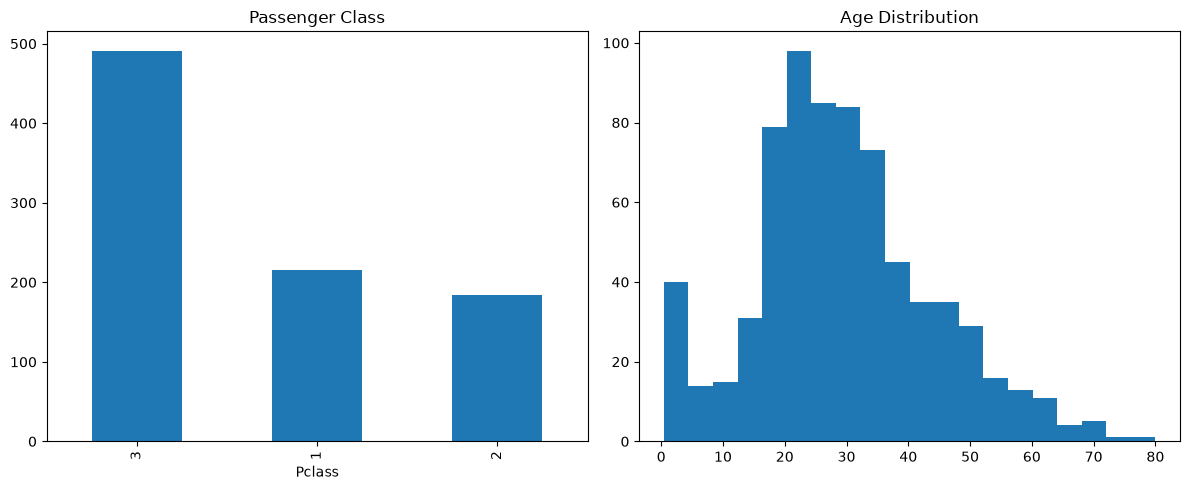

In [8]:
plt.figure(figsize=(12,5))

# First subplot
plt.subplot(1,2,1)
df["Pclass"].value_counts().plot(kind="bar")
plt.title("Passenger Class")

# Second subplot
plt.subplot(1,2,2)
plt.hist(df["Age"].dropna(), bins=20)
plt.title("Age Distribution")

plt.tight_layout()

plt.show()

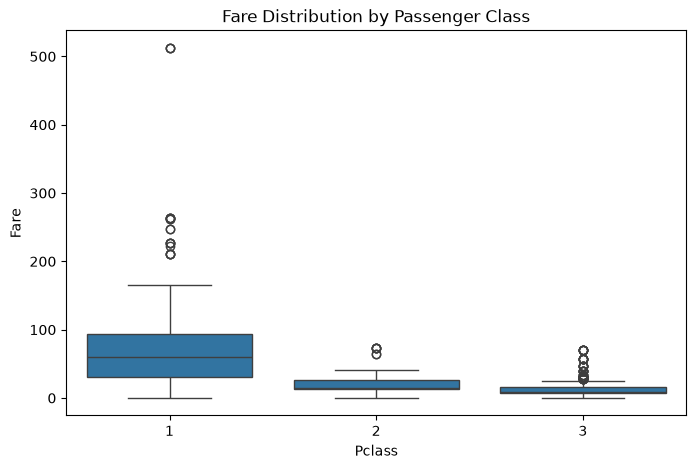

In [9]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Pclass", y="Fare", data=df)

plt.title("Fare Distribution by Passenger Class")

plt.show()

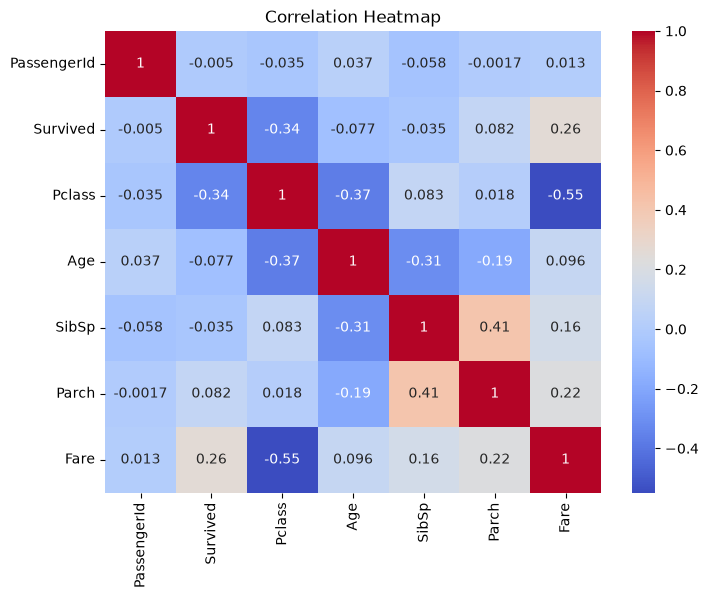

In [10]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

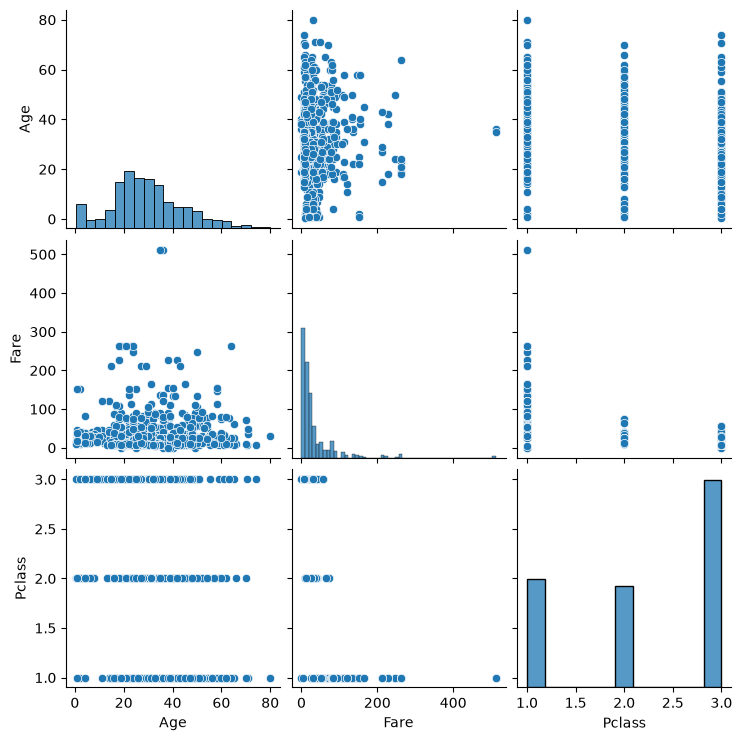

In [11]:
sns.pairplot(df[["Age", "Fare", "Pclass"]].dropna())

plt.show()

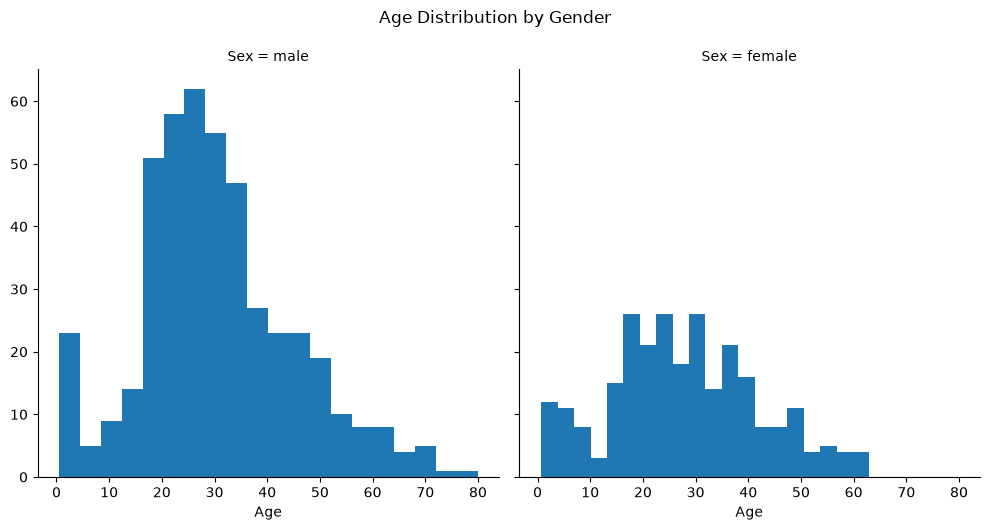

In [12]:
g = sns.FacetGrid(df, col="Sex", height=5)

g.map(plt.hist, "Age", bins=20)

g.fig.suptitle("Age Distribution by Gender", y=1.05)

plt.show()

In [13]:
fig = px.bar(
    df,
    x="Pclass",
    title="Passenger Class Distribution",
    color="Pclass"
)

fig.show()

In [14]:
fig = px.scatter(
    df,
    x="Age",
    y="Fare",
    color="Survived",
    title="Age vs Fare (Survival Status)",
    hover_data=["Name", "Sex"]
)

fig.show()

In [15]:
avg_fare = df.groupby("Pclass", as_index=False)["Fare"].mean()

fig = px.line(
    avg_fare,
    x="Pclass",
    y="Fare",
    markers=True,
    title="Average Fare by Passenger Class"
)

fig.show()

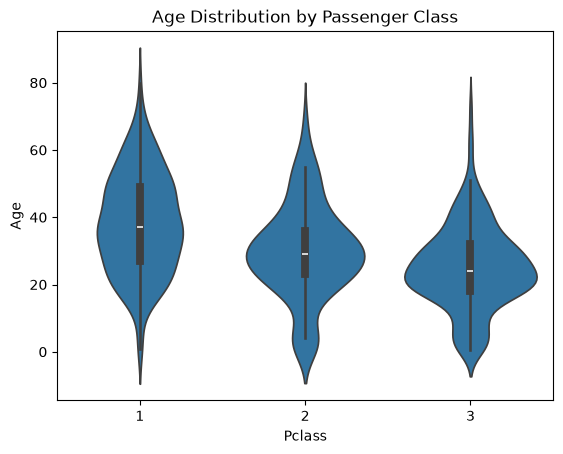

In [16]:
sns.violinplot(data=df, x="Pclass", y="Age")
plt.title("Age Distribution by Passenger Class")
plt.show()

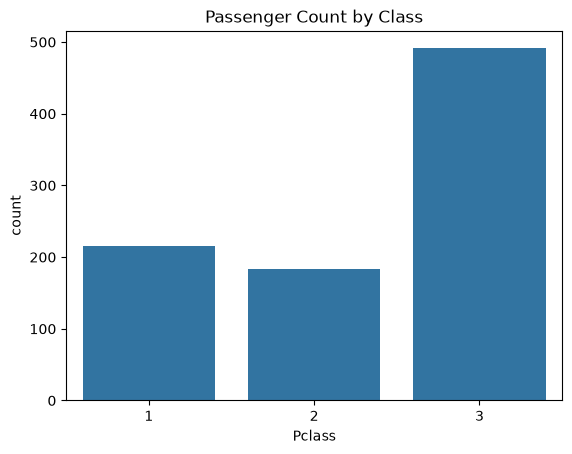

In [17]:
sns.countplot(data=df, x="Pclass")
plt.title("Passenger Count by Class")
plt.show()

In [18]:
fig = px.pie(
    df,
    names="Sex",
    title="Passenger Distribution by Sex"
)

fig.show()

In [19]:
fig.write_html("../reports/interactive_dashboard.html")

In [20]:
import pandas as pd
import plotly.express as px
import plotly.io as pio

pio.renderers.default = "notebook"

In [21]:
import plotly.io as pio
pio.renderers.default = "png"